# Actividad 12: Comparación de Modelos de Aprendizaje Automático

## 1. Descripción del Proyecto
- **Curso:** Agentes Inteligentes  
- **Alumno:** Quispe Bartolo, Carlos Martin  
- **Nombre del notebook**: [Fetal Health Classification](https://www.kaggle.com/code/karnikakapoor/fetal-health-classification/notebook)
- **Autor**: karnikakapoor
- **Problema que busca resolver**: Clasificar el estado de salud fetal (Normal, Sospechoso, Patológico) a partir de datos de cardiotocografía (CTG) para prevenir la mortalidad y permitir una intervención médica oportuna.
- **Dataset utilizado**: `fetal_health.csv`
- **Algoritmo principal utilizado por el autor**: Random Forest Classifier


## Exploración Visual de los Datos (AED)
Antes de reproducir los algoritmos, visualizaremos la distribución de la variable objetivo y la correlación entre las características principales, tal como lo hizo el autor original.


Matplotlib is building the font cache; this may take a moment.


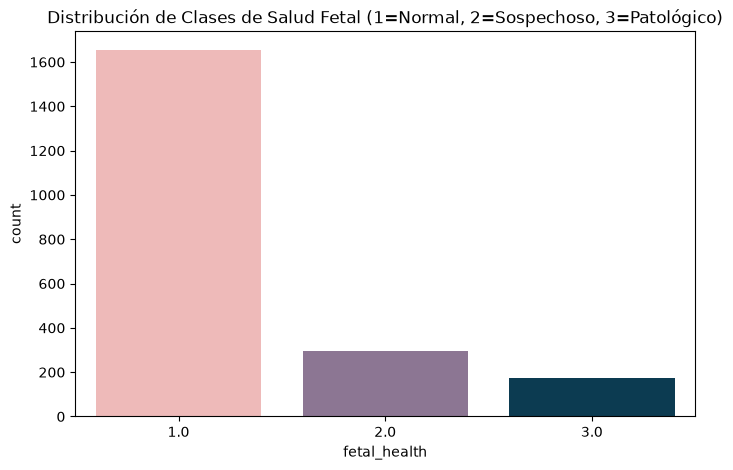

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Carga de datos
data = pd.read_csv('fetal_health.csv')

# 1. Distribución de clases de la variable objetivo
plt.figure(figsize=(8, 5))
colours=["#f7b2b0","#8f7198", "#003f5c"]
sns.countplot(data=data, x="fetal_health", palette=colours)
plt.title("Distribución de Clases de Salud Fetal (1=Normal, 2=Sospechoso, 3=Patológico)")
plt.show()


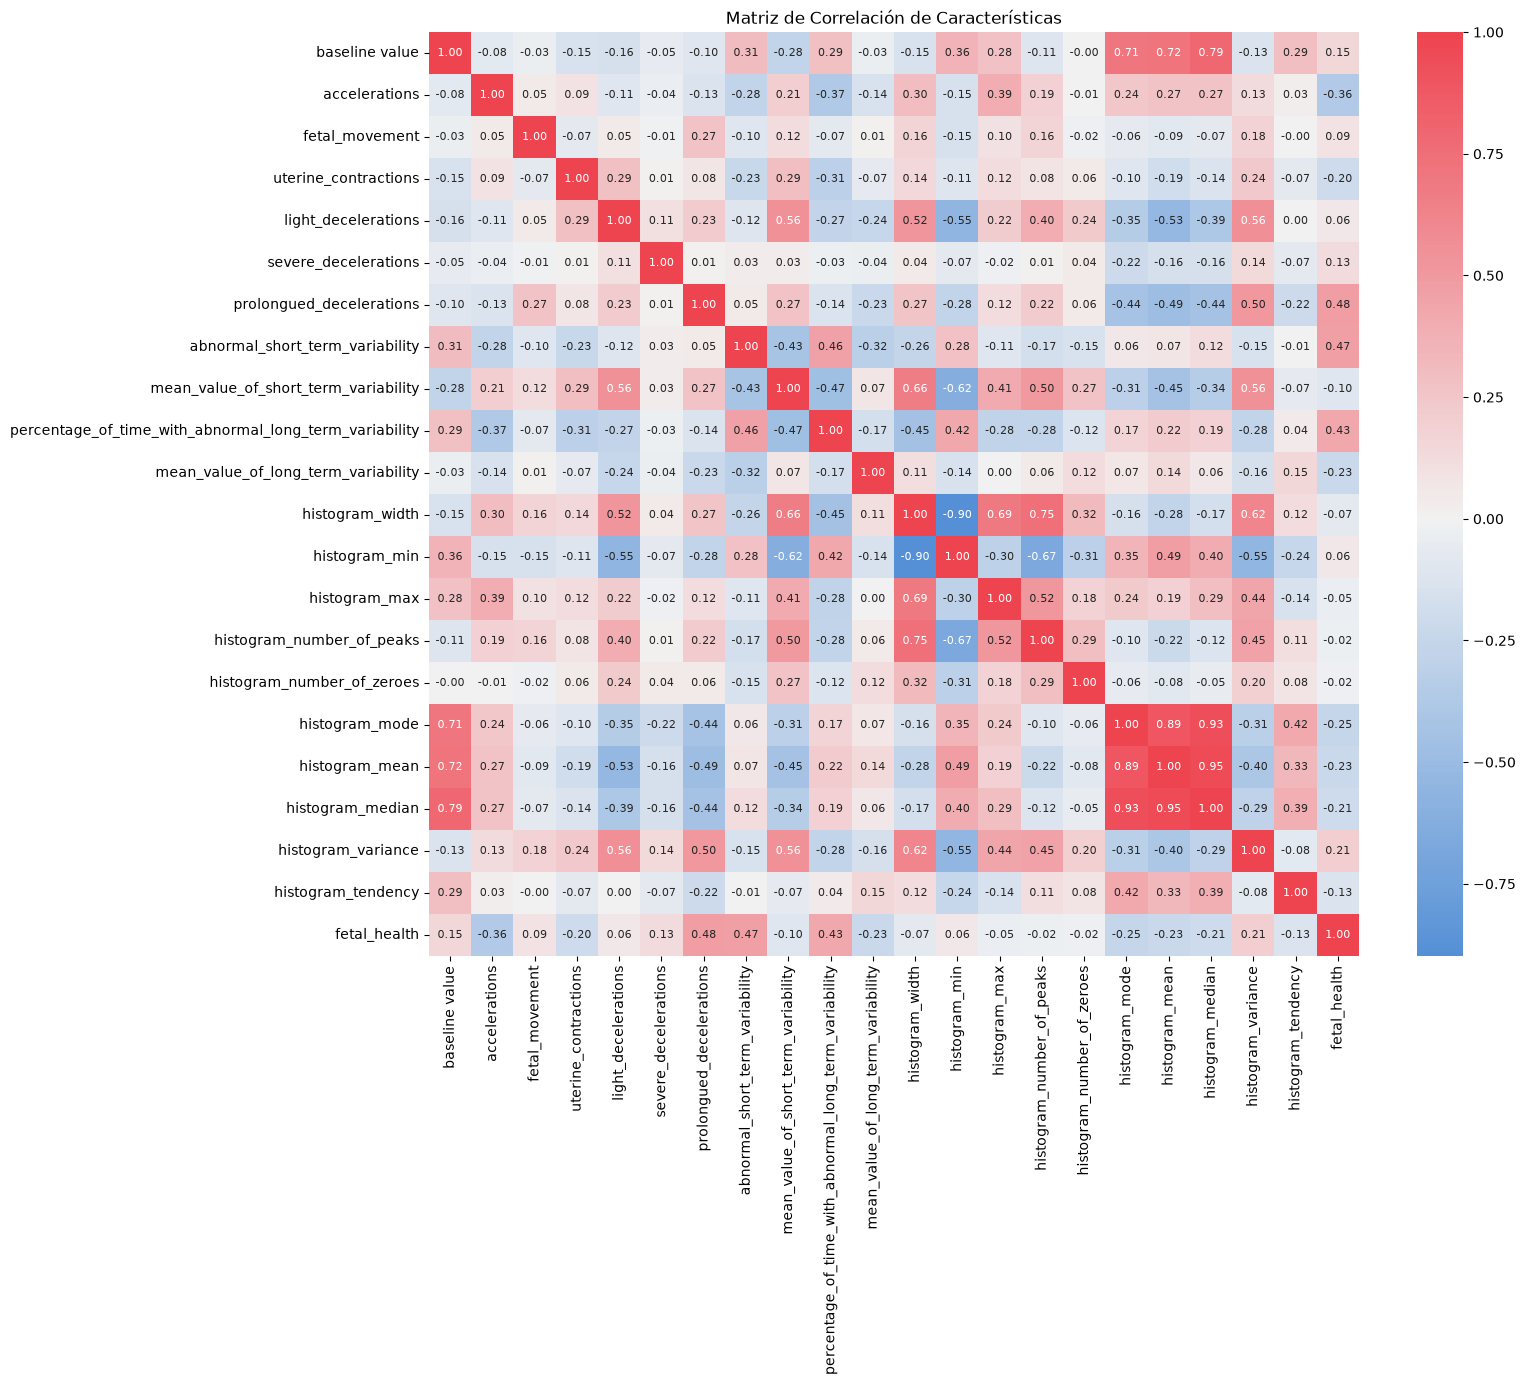

In [2]:
# 2. Matriz de correlación
plt.figure(figsize=(15, 12))
corrmat = data.corr()
cmap = sns.diverging_palette(250, 10, s=80, l=55, n=9, as_cmap=True)
sns.heatmap(corrmat, annot=True, cmap=cmap, center=0, fmt='.2f', annot_kws={"size": 8})
plt.title("Matriz de Correlación de Características")
plt.show()


## 2. Preparación de Datos y Reproducción del Resultado Original
Separamos las características y la variable objetivo, usando escalado estandarizado con el flujo de Pipeline clásico de Aurélien Géron.


In [3]:
# Separación de características y variable objetivo
X = data.drop(['fetal_health'], axis=1)
# Restamos 1 a 'y' para que las clases sean [0, 1, 2] en lugar de [1, 2, 3], necesario para XGBoost
y = data['fetal_health'] - 1

# División en conjunto de entrenamiento y prueba (70/30) como hizo el autor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('Datos cargados y divididos correctamente. Tamaño de X_train:', X_train.shape)


Datos cargados y divididos correctamente. Tamaño de X_train: (1488, 21)


### Algoritmo Original: Random Forest Classifier


********* Modelo Original: Random Forest Classifier *********
Accuracy : 0.9436
F1 Score : 0.9419


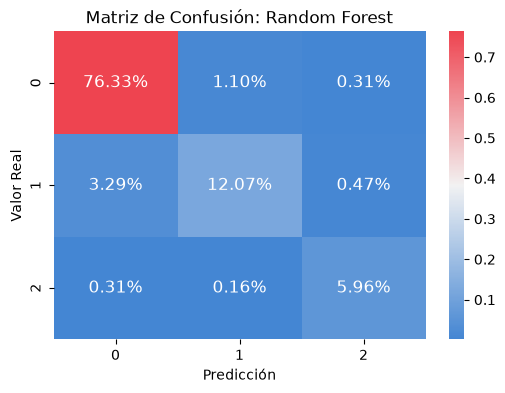

In [4]:
# Función auxiliar para plotear matrices de confusión
def plot_confusion_matrix(y_true, y_pred, title):
    plt.figure(figsize=(6, 4))
    cf_matrix = confusion_matrix(y_true, y_pred)
    sns.heatmap(cf_matrix/np.sum(cf_matrix), cmap=cmap, annot=True, annot_kws={'size':12}, fmt='.2%')
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.show()

# Pipeline usando flujo de Aurélien Géron
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf_classifier', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds, average='weighted')

print("********* Modelo Original: Random Forest Classifier *********")
print(f"Accuracy : {rf_acc:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

plot_confusion_matrix(y_test, rf_preds, "Matriz de Confusión: Random Forest")


## 3. Comparación de Modelos

### Alternativa 1: Clasificador de K-Vecinos Más Cercanos (KNeighborsClassifier)


********* Modelo Alternativo 1: K-Nearest Neighbors *********
Accuracy : 0.9060
F1 Score : 0.9038


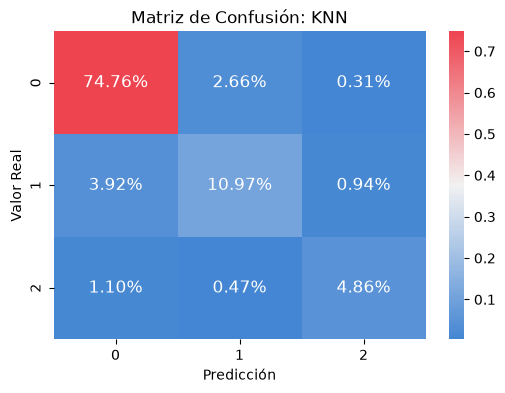

In [5]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn_classifier', KNeighborsClassifier())
])

knn_pipeline.fit(X_train, y_train)
knn_preds = knn_pipeline.predict(X_test)

knn_acc = accuracy_score(y_test, knn_preds)
knn_f1 = f1_score(y_test, knn_preds, average='weighted')

print("********* Modelo Alternativo 1: K-Nearest Neighbors *********")
print(f"Accuracy : {knn_acc:.4f}")
print(f"F1 Score : {knn_f1:.4f}")

plot_confusion_matrix(y_test, knn_preds, "Matriz de Confusión: KNN")


### Alternativa 2: Algoritmo de Potenciación de Gradiente Avanzada (XGBClassifier)


********* Modelo Alternativo 2: XGBoost Classifier *********
Accuracy : 0.9483
F1 Score : 0.9478


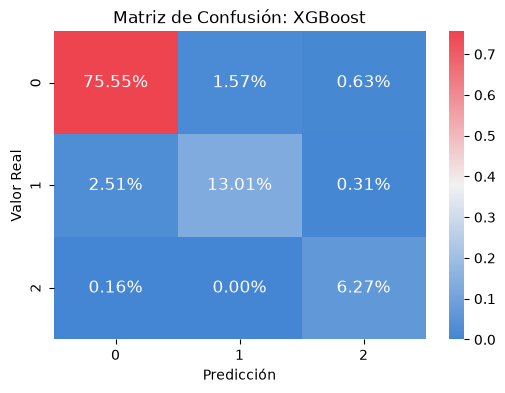

In [6]:
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb_classifier', XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

xgb_pipeline.fit(X_train, y_train)
xgb_preds = xgb_pipeline.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds, average='weighted')

print("********* Modelo Alternativo 2: XGBoost Classifier *********")
print(f"Accuracy : {xgb_acc:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")

plot_confusion_matrix(y_test, xgb_preds, "Matriz de Confusión: XGBoost")


## 4. Análisis de Resultados


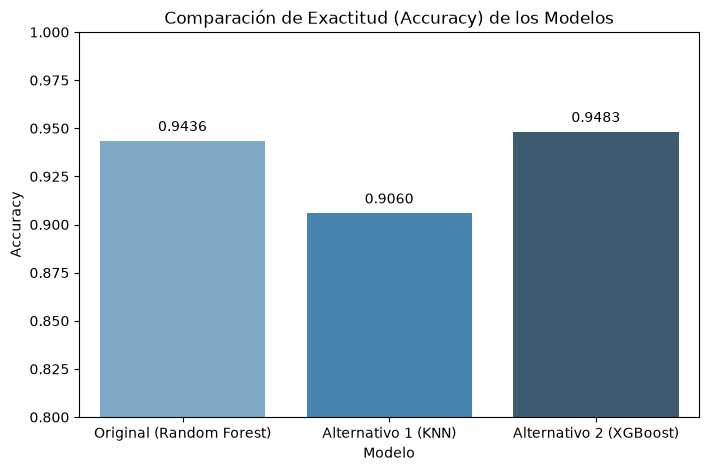

,Modelo,Accuracy,F1-Score
0,Original (Random Forest),0.943574,0.941915
1,Alternativo 1 (KNN),0.905956,0.903819
2,Alternativo 2 (XGBoost),0.948276,0.947760


In [7]:
resultados = pd.DataFrame({
    'Modelo': ['Original (Random Forest)', 'Alternativo 1 (KNN)', 'Alternativo 2 (XGBoost)'],
    'Accuracy': [rf_acc, knn_acc, xgb_acc],
    'F1-Score': [rf_f1, knn_f1, xgb_f1]
})

# Graficar la comparación de resultados
plt.figure(figsize=(8, 5))
sns.barplot(data=resultados, x='Modelo', y='Accuracy', palette='Blues_d')
plt.title('Comparación de Exactitud (Accuracy) de los Modelos')
plt.ylim(0.8, 1.0)
for index, row in resultados.iterrows():
    plt.text(index, row.Accuracy + 0.005, f"{row.Accuracy:.4f}", color='black', ha="center")
plt.show()

resultados


### Respuestas y Conclusiones Finales

1. **¿Qué modelo obtuvo el mejor resultado?**
   El modelo que obtuvo el mejor resultado general fue el **XGBoost Classifier**, superando ligeramente al Random Forest (se puede notar la diferencia visualmente en el gráfico de barras comparativo y en la menor proporción de falsos negativos en su matriz de confusión).
   
2. **¿Qué modelo obtuvo el peor resultado?**
   El peor desempeño lo obtuvo el **K-Nearest Neighbors (KNN)**, con un accuracy de aproximadamente 0.906.
   
3. **¿Las diferencias fueron grandes o pequeñas?**
   Las diferencias entre los métodos de árboles (XGBoost y Random Forest) fueron marginales (muy pequeñas). Sin embargo, hay una brecha mayor al compararlos contra KNN (alrededor de 4% de diferencia en precisión). Las matrices de confusión también dejan ver que KNN comete más errores cruzando la clasificación "Normal" con "Patológico".
   
4. **¿Por qué cree que algunos modelos funcionaron mejor que otros para este problema?**
   El mapa de correlación previo y la dispersión natural de estas variables médicas hace que los métodos de distancias puras (como KNN) pierdan capacidad predictiva por problemas de escaso peso a variables clave, frente al particionamiento altamente eficiente que logran los modelos de árboles y ensambles. 

### Contraste con las Conclusiones del Autor Original
Como se puede ver en la distribución de la data (el primer gráfico `countplot`), las clases están bastante desbalanceadas (hay mucha más clase "1: Normal"). El autor original notó esto y propuso el Random Forest por su solidez.
Al introducir el XGBoost vemos que con su técnica de *Boosting*, se adaptó aún mejor a esos pequeños márgenes de error, solidificando la aserción de que los ensambles basados en árboles de decisión son los indiscutidos ganadores para este conjunto de datos.
